In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('sales.csv')
df.head()

,sale_id,branch,city,customer_type,gender,product_name,product_category,unit_price,quantity,tax,total_price,reward_points
0,1,A,New York,Member,Male,Shampoo,Personal Care,5.50,3,1.16,17.66,1
1,2,B,Los Angeles,Normal,Female,Notebook,Stationery,2.75,10,1.93,29.43,0
2,3,A,New York,Member,Female,Apple,Fruits,1.20,15,1.26,19.26,1
3,4,A,Chicago,Normal,Male,Detergent,Household,7.80,5,2.73,41.73,0
4,5,B,Los Angeles,Member,Female,Orange Juice,Beverages,3.50,7,1.72,26.22,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sale_id           1000 non-null   int64  
 1   branch            1000 non-null   object 
 2   city              1000 non-null   object 
 3   customer_type     1000 non-null   object 
 4   gender            1000 non-null   object 
 5   product_name      1000 non-null   object 
 6   product_category  1000 non-null   object 
 7   unit_price        1000 non-null   float64
 8   quantity          1000 non-null   int64  
 9   tax               1000 non-null   float64
 10  total_price       1000 non-null   float64
 11  reward_points     1000 non-null   int64  
dtypes: float64(3), int64(3), object(6)
memory usage: 93.9+ KB


In [6]:
df.describe()

,sale_id,unit_price,quantity,tax,total_price,reward_points
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,10.836110,10.337000,7.758010,118.583900,6.057000
std,288.819436,5.775924,6.029908,6.538066,99.936441,9.350464
min,1.000000,1.020000,1.000000,0.080000,1.210000,0.000000
25%,250.750000,5.867500,5.000000,2.510000,38.380000,0.000000
50%,500.500000,10.615000,10.000000,5.870000,89.705000,0.000000
75%,750.250000,15.882500,16.000000,11.522500,176.072500,10.000000
max,1000.000000,20.980000,20.000000,28.390000,433.990000,43.000000


In [7]:
#nulls
df.isnull().sum()

sale_id             0
branch              0
city                0
customer_type       0
gender              0
product_name        0
product_category    0
unit_price          0
quantity            0
tax                 0
total_price         0
reward_points       0
dtype: int64

In [8]:
#duplicates
df.duplicated().sum()

np.int64(0)

In [11]:
df.shape


(1000, 12)

In [13]:
#add order_date
np.random.seed(42)
dates=sorted(
    np.random.choice(pd.date_range('2024-01-01','2024-12-31'),size=len(df)))
df.insert(1,'Order_date',pd.to_datetime(dates))

print(f"Shape: {df.shape}")
print(df.dtypes)
df.head()

ValueError: cannot insert Order_date, already exists

In [14]:
df.head()

,sale_id,Order_date,branch,city,customer_type,gender,product_name,product_category,unit_price,quantity,tax,total_price,reward_points
0,1,2024-01-01,A,New York,Member,Male,Shampoo,Personal Care,5.50,3,1.16,17.66,1
1,2,2024-01-01,B,Los Angeles,Normal,Female,Notebook,Stationery,2.75,10,1.93,29.43,0
2,3,2024-01-01,A,New York,Member,Female,Apple,Fruits,1.20,15,1.26,19.26,1
3,4,2024-01-01,A,Chicago,Normal,Male,Detergent,Household,7.80,5,2.73,41.73,0
4,5,2024-01-01,B,Los Angeles,Member,Female,Orange Juice,Beverages,3.50,7,1.72,26.22,2


In [15]:
print(f"Shape: {df.shape}")
print(df.dtypes)

Shape: (1000, 13)
sale_id                      int64
Order_date          datetime64[ns]
branch                      object
city                        object
customer_type               object
gender                      object
product_name                object
product_category            object
unit_price                 float64
quantity                     int64
tax                        float64
total_price                float64
reward_points                int64
dtype: object


In [17]:
#data quality check
print("null values")
df.isnull().sum()


null values


sale_id             0
Order_date          0
branch              0
city                0
customer_type       0
gender              0
product_name        0
product_category    0
unit_price          0
quantity            0
tax                 0
total_price         0
reward_points       0
dtype: int64

In [18]:
print("duplicates ")
df.duplicated().sum()

duplicates 


np.int64(0)

In [21]:
print("Negative prices ")
(df['total_price']<0).sum()

Negative prices 


np.int64(0)

In [22]:
print("Zero quantities ")
(df['quantity']==0).sum()

Zero quantities 


np.int64(0)

In [24]:
print('Date range')
df['Order_date'].min().date()
df['Order_date'].max().date()

Date range


datetime.date(2024, 12, 31)

In [26]:
df['month']=df['Order_date'].dt.to_period('M')
df.head()

,sale_id,Order_date,branch,city,customer_type,gender,product_name,product_category,unit_price,quantity,tax,total_price,reward_points,month
0,1,2024-01-01,A,New York,Member,Male,Shampoo,Personal Care,5.50,3,1.16,17.66,1,2024-01
1,2,2024-01-01,B,Los Angeles,Normal,Female,Notebook,Stationery,2.75,10,1.93,29.43,0,2024-01
2,3,2024-01-01,A,New York,Member,Female,Apple,Fruits,1.20,15,1.26,19.26,1,2024-01
3,4,2024-01-01,A,Chicago,Normal,Male,Detergent,Household,7.80,5,2.73,41.73,0,2024-01
4,5,2024-01-01,B,Los Angeles,Member,Female,Orange Juice,Beverages,3.50,7,1.72,26.22,2,2024-01


In [28]:
df['month_name']=df['Order_date'].dt.strftime('%b')
df.head()

,sale_id,Order_date,branch,city,customer_type,gender,product_name,product_category,unit_price,quantity,tax,total_price,reward_points,month,month_name
0,1,2024-01-01,A,New York,Member,Male,Shampoo,Personal Care,5.50,3,1.16,17.66,1,2024-01,Jan
1,2,2024-01-01,B,Los Angeles,Normal,Female,Notebook,Stationery,2.75,10,1.93,29.43,0,2024-01,Jan
2,3,2024-01-01,A,New York,Member,Female,Apple,Fruits,1.20,15,1.26,19.26,1,2024-01,Jan
3,4,2024-01-01,A,Chicago,Normal,Male,Detergent,Household,7.80,5,2.73,41.73,0,2024-01,Jan
4,5,2024-01-01,B,Los Angeles,Member,Female,Orange Juice,Beverages,3.50,7,1.72,26.22,2,2024-01,Jan


In [30]:
df['month_num']=df['Order_date'].dt.month
df.head()

,sale_id,Order_date,branch,city,customer_type,gender,product_name,product_category,unit_price,quantity,tax,total_price,reward_points,month,month_name,month_num
0,1,2024-01-01,A,New York,Member,Male,Shampoo,Personal Care,5.50,3,1.16,17.66,1,2024-01,Jan,1
1,2,2024-01-01,B,Los Angeles,Normal,Female,Notebook,Stationery,2.75,10,1.93,29.43,0,2024-01,Jan,1
2,3,2024-01-01,A,New York,Member,Female,Apple,Fruits,1.20,15,1.26,19.26,1,2024-01,Jan,1
3,4,2024-01-01,A,Chicago,Normal,Male,Detergent,Household,7.80,5,2.73,41.73,0,2024-01,Jan,1
4,5,2024-01-01,B,Los Angeles,Member,Female,Orange Juice,Beverages,3.50,7,1.72,26.22,2,2024-01,Jan,1


In [31]:
df['quarter']='Q'+df['Order_date'].dt.quarter.astype(str)
df.head()

,sale_id,Order_date,branch,city,customer_type,gender,product_name,product_category,unit_price,quantity,tax,total_price,reward_points,month,month_name,month_num,quarter
0,1,2024-01-01,A,New York,Member,Male,Shampoo,Personal Care,5.50,3,1.16,17.66,1,2024-01,Jan,1,Q1
1,2,2024-01-01,B,Los Angeles,Normal,Female,Notebook,Stationery,2.75,10,1.93,29.43,0,2024-01,Jan,1,Q1
2,3,2024-01-01,A,New York,Member,Female,Apple,Fruits,1.20,15,1.26,19.26,1,2024-01,Jan,1,Q1
3,4,2024-01-01,A,Chicago,Normal,Male,Detergent,Household,7.80,5,2.73,41.73,0,2024-01,Jan,1,Q1
4,5,2024-01-01,B,Los Angeles,Member,Female,Orange Juice,Beverages,3.50,7,1.72,26.22,2,2024-01,Jan,1,Q1


In [32]:
df['day_of_week']=df['Order_date'].dt.day_name()
df.head()

,sale_id,Order_date,branch,city,customer_type,gender,product_name,product_category,unit_price,quantity,tax,total_price,reward_points,month,month_name,month_num,quarter,day_of_week
0,1,2024-01-01,A,New York,Member,Male,Shampoo,Personal Care,5.50,3,1.16,17.66,1,2024-01,Jan,1,Q1,Monday
1,2,2024-01-01,B,Los Angeles,Normal,Female,Notebook,Stationery,2.75,10,1.93,29.43,0,2024-01,Jan,1,Q1,Monday
2,3,2024-01-01,A,New York,Member,Female,Apple,Fruits,1.20,15,1.26,19.26,1,2024-01,Jan,1,Q1,Monday
3,4,2024-01-01,A,Chicago,Normal,Male,Detergent,Household,7.80,5,2.73,41.73,0,2024-01,Jan,1,Q1,Monday
4,5,2024-01-01,B,Los Angeles,Member,Female,Orange Juice,Beverages,3.50,7,1.72,26.22,2,2024-01,Jan,1,Q1,Monday


In [33]:
df['price_tier']=pd.cut(df['unit_price'],
                        bins=[0,5,10,15,21],
                        labels=['Budget','Mid','Premium','Luxury'])
df.head()

,sale_id,Order_date,branch,city,customer_type,gender,product_name,product_category,unit_price,quantity,tax,total_price,reward_points,month,month_name,month_num,quarter,day_of_week,price_tier
0,1,2024-01-01,A,New York,Member,Male,Shampoo,Personal Care,5.50,3,1.16,17.66,1,2024-01,Jan,1,Q1,Monday,Mid
1,2,2024-01-01,B,Los Angeles,Normal,Female,Notebook,Stationery,2.75,10,1.93,29.43,0,2024-01,Jan,1,Q1,Monday,Budget
2,3,2024-01-01,A,New York,Member,Female,Apple,Fruits,1.20,15,1.26,19.26,1,2024-01,Jan,1,Q1,Monday,Budget
3,4,2024-01-01,A,Chicago,Normal,Male,Detergent,Household,7.80,5,2.73,41.73,0,2024-01,Jan,1,Q1,Monday,Mid
4,5,2024-01-01,B,Los Angeles,Member,Female,Orange Juice,Beverages,3.50,7,1.72,26.22,2,2024-01,Jan,1,Q1,Monday,Budget


In [34]:
df[['Order_date','month_name','quarter','price_tier','total_price']].head()

,Order_date,month_name,quarter,price_tier,total_price
0,2024-01-01,Jan,Q1,Mid,17.66
1,2024-01-01,Jan,Q1,Budget,29.43
2,2024-01-01,Jan,Q1,Budget,19.26
3,2024-01-01,Jan,Q1,Mid,41.73
4,2024-01-01,Jan,Q1,Budget,26.22


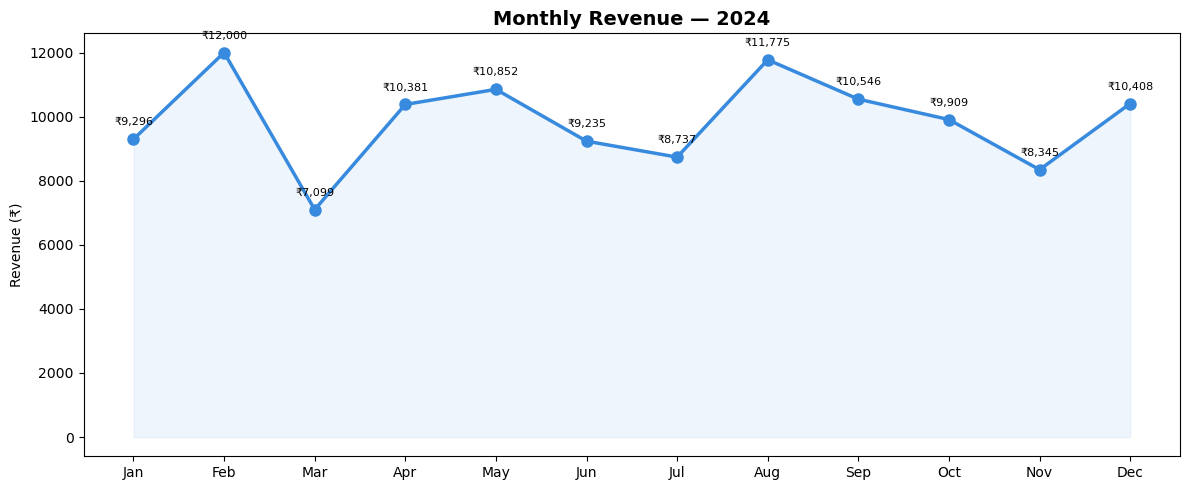

Peak: Feb
Low:  Mar


In [35]:
#monthly revenue trend
monthly = (df.groupby(['month_num','month_name'])['total_price']
             .sum().reset_index()
             .sort_values('month_num'))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly['month_name'], monthly['total_price'],
        marker='o', color='#378ADD', linewidth=2.5, markersize=8)
ax.fill_between(range(12), monthly['total_price'], alpha=0.08, color='#378ADD')

for i, row in monthly.iterrows():
    ax.annotate(f"₹{row['total_price']:,.0f}",
                (row['month_name'], row['total_price']),
                textcoords="offset points", xytext=(0,10),
                ha='center', fontsize=8)

ax.set_title('Monthly Revenue — 2024', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue (₹)')
plt.xticks(range(12), monthly['month_name'])
plt.tight_layout()
plt.show()

print(f"Peak: {monthly.loc[monthly['total_price'].idxmax(),'month_name']}")
print(f"Low:  {monthly.loc[monthly['total_price'].idxmin(),'month_name']}")


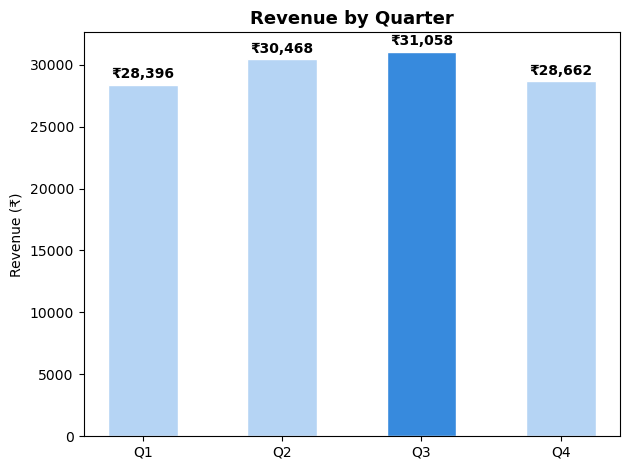

In [36]:
#quarterly comparison
qtr = df.groupby('quarter')['total_price'].sum().reset_index()

colors = ['#378ADD' if v==qtr['total_price'].max()
          else '#B5D4F4' for v in qtr['total_price']]
plt.bar(qtr['quarter'], qtr['total_price'], color=colors, edgecolor='white', width=0.5)
plt.title('Revenue by Quarter', fontsize=13, fontweight='bold')
plt.ylabel('Revenue (₹)')

for i, row in qtr.iterrows():
    plt.text(i, row['total_price']+500, f"₹{row['total_price']:,.0f}",
             ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

                   revenue  orders  avg_value
product_category                             
Personal Care     27050.18     208     130.05
Fruits            26197.45     209     125.35
Beverages         22983.32     187     122.91
Household         21615.84     198     109.17
Stationery        20737.11     198     104.73


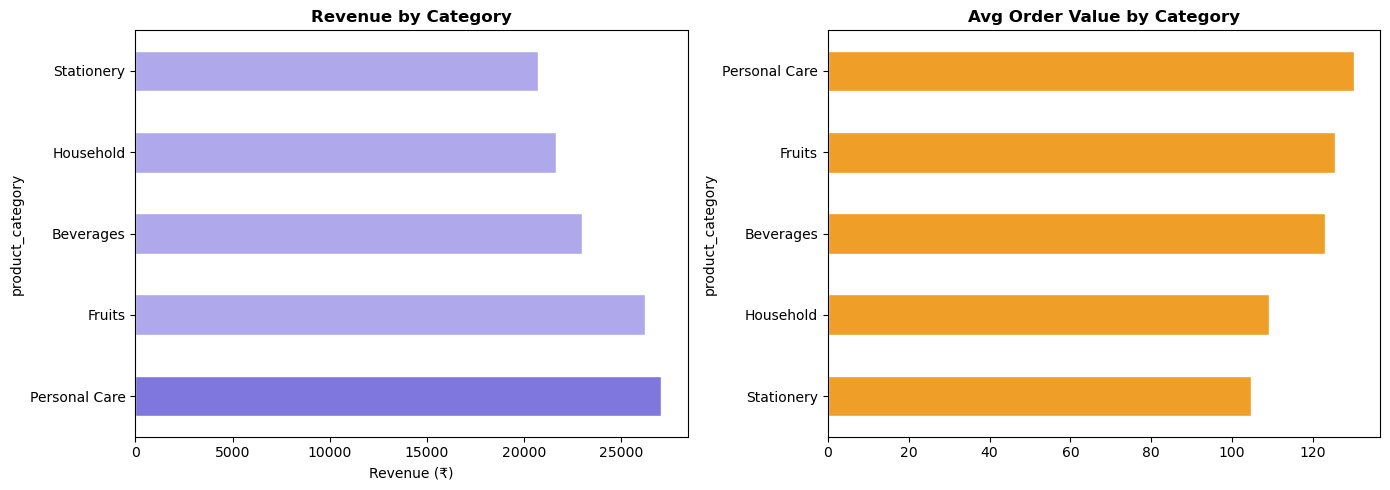

In [37]:
#category
cat = df.groupby('product_category').agg(
    revenue   = ('total_price', 'sum'),
    orders    = ('sale_id',     'count'),
    avg_value = ('total_price', 'mean')
).sort_values('revenue', ascending=False).round(2)
print(cat)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue bar
cat['revenue'].plot(kind='barh', ax=axes[0],
    color=['#7F77DD','#AFA9EC','#AFA9EC','#AFA9EC','#AFA9EC'],
    edgecolor='white')
axes[0].set_title('Revenue by Category', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Revenue (₹)')

# Avg order value
cat['avg_value'].sort_values().plot(kind='barh', ax=axes[1],
    color='#EF9F27', edgecolor='white')
axes[1].set_title('Avg Order Value by Category', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


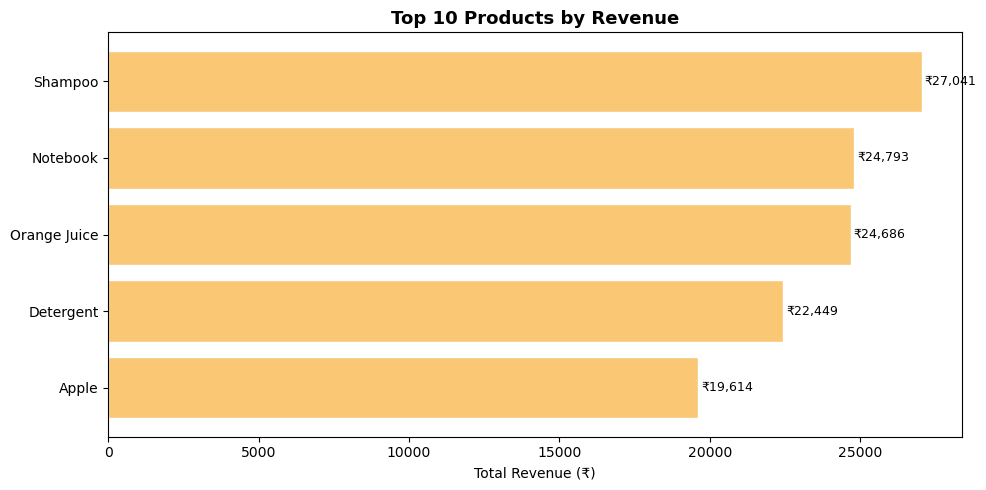

In [39]:
#top 10 products
top10 = (df.groupby('product_name')['total_price']
           .sum().sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#EF9F27' if i==0 else '#FAC775' for i in range(10)]
ax.barh(top10.index[::-1], top10.values[::-1],
        color=colors[::-1], edgecolor='white')
ax.set_title('Top 10 Products by Revenue', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Revenue (₹)')
for i, (name, val) in enumerate(zip(top10.index[::-1], top10.values[::-1])):
    ax.text(val+100, i, f'₹{val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

               orders   revenue  avg_spend  avg_qty  avg_pts
customer_type                                               
Member            516  63213.63     122.51    10.46    11.74
Normal            484  55370.27     114.40    10.21     0.00


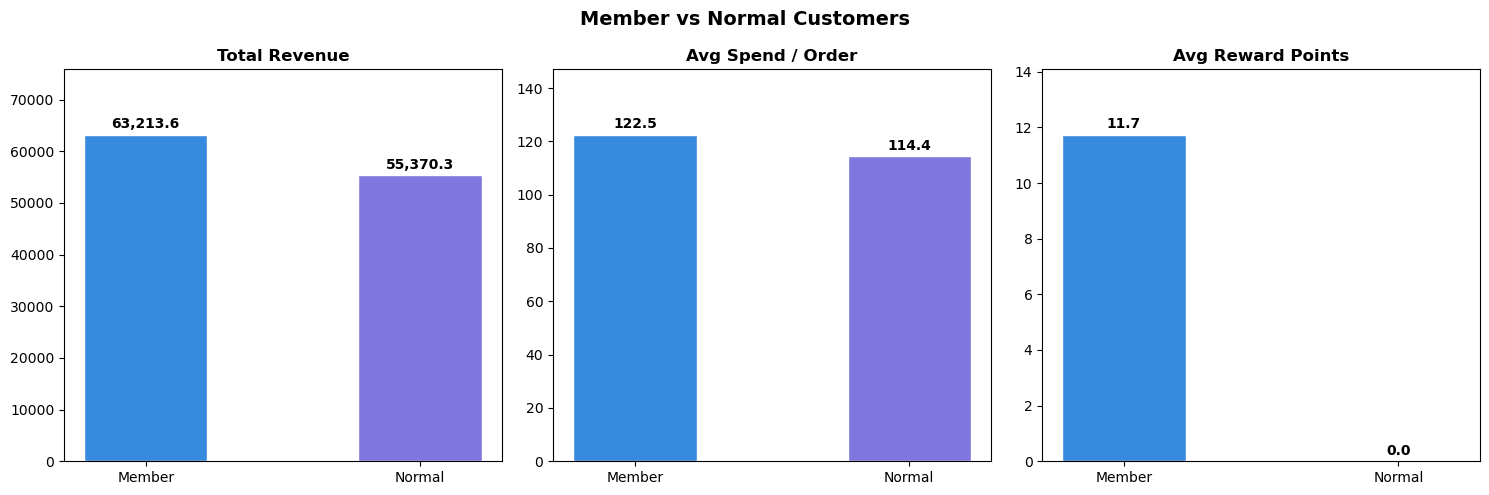

In [40]:
#member vs mormal

seg = df.groupby('customer_type').agg(
    orders    = ('sale_id',       'count'),
    revenue   = ('total_price',   'sum'),
    avg_spend = ('total_price',   'mean'),
    avg_qty   = ('quantity',      'mean'),
    avg_pts   = ('reward_points', 'mean')
).round(2)
print(seg)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = [('revenue','Total Revenue'),
           ('avg_spend','Avg Spend / Order'),
           ('avg_pts','Avg Reward Points')]
colors = ['#378ADD','#7F77DD']

for i,(col,title) in enumerate(metrics):
    bars = axes[i].bar(seg.index, seg[col], color=colors,
                       edgecolor='white', width=0.45)
    for bar,val in zip(bars, seg[col]):
        axes[i].text(bar.get_x()+bar.get_width()/2,
                     bar.get_height()+seg[col].max()*0.02,
                     f'{val:,.1f}', ha='center', fontsize=10, fontweight='bold')
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_ylim(0, seg[col].max()*1.2)

plt.suptitle('Member vs Normal Customers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

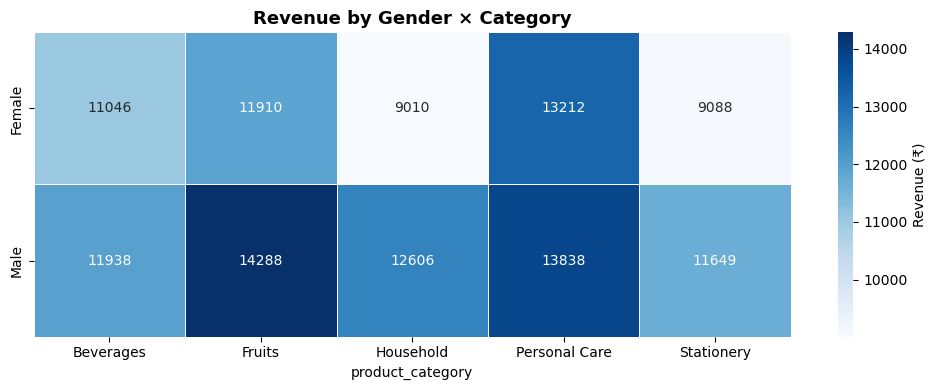


Gender summary:
        count       sum    mean
gender                         
Female    472  54265.45  114.97
Male      528  64318.45  121.82


In [41]:
#gender x category heatmap

pivot = df.pivot_table(
    values='total_price',
    index='gender',
    columns='product_category',
    aggfunc='sum').round(0)

plt.figure(figsize=(10, 4))
sns.heatmap(pivot, annot=True, fmt='.0f',
            cmap='Blues', linewidths=0.5,
            cbar_kws={'label':'Revenue (₹)'})
plt.title('Revenue by Gender × Category', fontsize=13, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

print("\nGender summary:")
print(df.groupby('gender')['total_price'].agg(['count','sum','mean']).round(2))


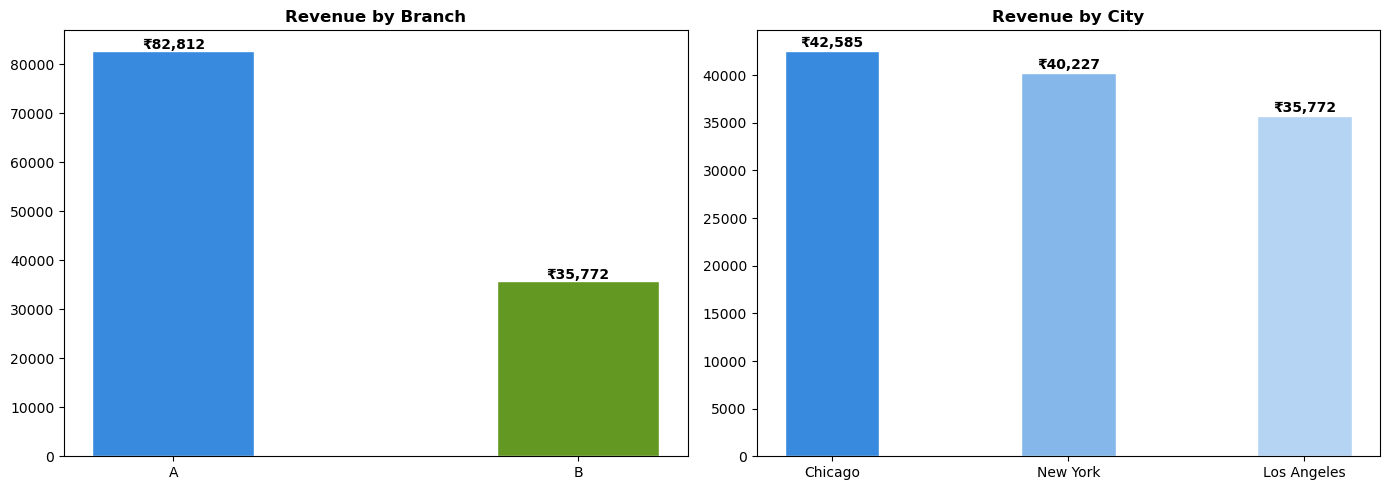

In [42]:
#branch and city

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Branch
branch = df.groupby('branch').agg(
    orders=('sale_id','count'), revenue=('total_price','sum'),
    avg=('total_price','mean')).round(2)
x = range(len(branch))
axes[0].bar(branch.index, branch['revenue'],
            color=['#378ADD','#639922'], edgecolor='white', width=0.4)
for i,val in enumerate(branch['revenue']):
    axes[0].text(i, val+400, f'₹{val:,.0f}',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Revenue by Branch', fontsize=12, fontweight='bold')

# City
city = df.groupby('city')['total_price'].sum().sort_values(ascending=False)
axes[1].bar(city.index, city.values,
            color=['#378ADD','#85B7EB','#B5D4F4'], edgecolor='white', width=0.4)
for i,val in enumerate(city.values):
    axes[1].text(i, val+400, f'₹{val:,.0f}',
                 ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Revenue by City', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

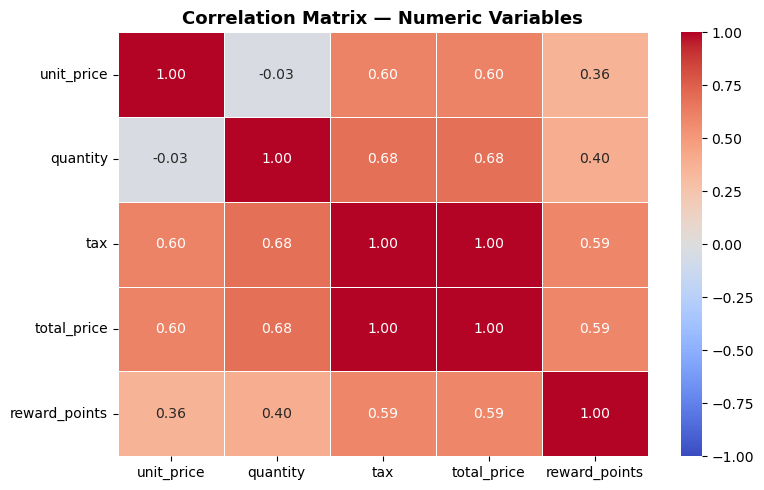

In [43]:
#correlation heatmap

# Shows relationships between numeric variables
num_cols = ['unit_price','quantity','tax','total_price','reward_points']
corr = df[num_cols].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix — Numeric Variables',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [44]:
#insight summary

print("=" * 55)
print("  CUSTOMER BEHAVIOR & SALES INSIGHTS — SUMMARY")
print("=" * 55)

total = df['total_price'].sum()
m_avg = df[df['customer_type']=='Member']['total_price'].mean()
n_avg = df[df['customer_type']=='Normal']['total_price'].mean()
lift  = (m_avg - n_avg) / n_avg * 100

print(f"""
OVERVIEW
  Total Revenue  : ₹{total:,.2f}
  Total Orders   : {len(df):,}
  Avg Order Value: ₹{df['total_price'].mean():.2f}

FINDINGS
  1. Branch A handles 67% of orders & 70% of revenue
     → Investigate Branch B capacity & marketing

  2. Members spend {lift:.1f}% more per order than Normal
     → Launch membership conversion campaign

  3. Personal Care & Fruits = 45% of revenue
     → Prioritise stock & promote these categories

  4. March is the lowest revenue month (₹7,099)
     → Run targeted promotions in Feb to pre-empt dip

  5. Chicago leads all cities (₹42,585)
     → Replicate Chicago strategy in Los Angeles

NEXT STEPS
  → Build a membership conversion prediction model
  → Forecast monthly revenue with Facebook Prophet
  → Create Power BI dashboard for stakeholder reporting
""")

  CUSTOMER BEHAVIOR & SALES INSIGHTS — SUMMARY

OVERVIEW
  Total Revenue  : ₹118,583.90
  Total Orders   : 1,000
  Avg Order Value: ₹118.58

FINDINGS
  1. Branch A handles 67% of orders & 70% of revenue
     → Investigate Branch B capacity & marketing

  2. Members spend 7.1% more per order than Normal
     → Launch membership conversion campaign

  3. Personal Care & Fruits = 45% of revenue
     → Prioritise stock & promote these categories

  4. March is the lowest revenue month (₹7,099)
     → Run targeted promotions in Feb to pre-empt dip

  5. Chicago leads all cities (₹42,585)
     → Replicate Chicago strategy in Los Angeles

NEXT STEPS
  → Build a membership conversion prediction model
  → Forecast monthly revenue with Facebook Prophet
  → Create Power BI dashboard for stakeholder reporting

